In [1]:
import pickle, time
import numpy as np
import pandas as pd
import scipy.sparse as sp
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

X_train = sp.load_npz('X_train_tfidf.npz')
X_test  = sp.load_npz('X_test_tfidf.npz')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test  = pd.read_csv('y_test.csv').values.ravel()

LABELS = ['negative', 'neutral', 'positive']


In [2]:
# Không gian tham số cần tìm
param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 4, 5, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2, 0.5]
}

base_model = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator  = base_model,
    param_distributions = param_dist,
    n_iter     = 30,          # thử 30 bộ tham số ngẫu nhiên
    scoring    = 'f1_weighted',
    cv         = cv,
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)

t = time.time()
search.fit(X_train, y_train)
print(f' Xong! {round(time.time()-t, 1)}s')
print(f'\nBest params: {search.best_params_}')
print(f'Best CV F1 : {search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
 Xong! 760.6s

Best params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best CV F1 : 0.7633


In [3]:
# ==================== SO SÁNH TRƯỚC VÀ SAU FINE-TUNING (trên Validation Set) ====================

# Load Validation set
X_val = sp.load_npz('X_val_tfidf.npz')
y_val = pd.read_csv('y_val.csv').values.ravel()

# Model trước tuning (baseline)
model_before = XGBClassifier(
    n_estimators=200, max_depth=6,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
).fit(X_train, y_train)

y_pred_before = model_before.predict(X_val)

# Model sau tuning
best_model = search.best_estimator_
y_pred_after = best_model.predict(X_val)

print('=' * 60)
print('SO SÁNH TRƯỚC VÀ SAU FINE-TUNING (trên Validation Set)')
print('=' * 60)

for label, y_pred in [('Trước tuning', y_pred_before), ('Sau tuning  ', y_pred_after)]:
    acc = accuracy_score(y_val, y_pred)
    f1w = f1_score(y_val, y_pred, average='weighted')
    f1m = f1_score(y_val, y_pred, average='macro')
    print(f'\n{label}: Acc={acc:.4f} | F1w={f1w:.4f} | F1m={f1m:.4f}')

print('\n Classification Report (sau tuning - Validation):')
print(classification_report(y_val, y_pred_after, target_names=LABELS))

SO SÁNH TRƯỚC VÀ SAU FINE-TUNING (trên Validation Set)

Trước tuning: Acc=0.7664 | F1w=0.7622 | F1m=0.6944

Sau tuning  : Acc=0.7632 | F1w=0.7587 | F1m=0.6895

 Classification Report (sau tuning - Validation):
              precision    recall  f1-score   support

    negative       0.83      0.88      0.85      1376
     neutral       0.59      0.54      0.57       465
    positive       0.70      0.61      0.65       355

    accuracy                           0.76      2196
   macro avg       0.71      0.68      0.69      2196
weighted avg       0.76      0.76      0.76      2196



In [4]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Chỉ áp dụng trên TRAIN set, KHÔNG đụng vào test set
t = time.time()

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f' Xong! {round(time.time()-t, 1)}s')
print(f'Phân phối TRƯỚC SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Phân phối SAU  SMOTE: {dict(zip(*np.unique(y_train_res, return_counts=True)))}')
print(f'Tổng mẫu train: {len(y_train):,} → {len(y_train_res):,}')

 Xong! 0.2s
Phân phối TRƯỚC SMOTE: {0: 6425, 1: 2169, 2: 1654}
Phân phối SAU  SMOTE: {0: 6425, 1: 6425, 2: 6425}
Tổng mẫu train: 10,248 → 19,275


In [5]:
best_params_smote = search.best_params_

model_smote  = XGBClassifier(
    **best_params_smote,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)

print(' Training XGBoost + SMOTE...')
t = time.time()
model_smote.fit(X_train_res, y_train_res)
y_pred_smote = model_smote.predict(X_val)

 Training XGBoost + SMOTE...


In [6]:
print(f'{"Version":<28} {"Accuracy":>10} {"F1 Weighted":>12} {"F1 Macro":>10}')
print('-' * 65)

for label, y_pred in [
    ('Baseline (default)',    y_pred_before),
    ('Fine-tuned (no SMOTE)', y_pred_after),
    ('Fine-tuned + SMOTE',    y_pred_smote)
]:
    acc = accuracy_score(y_val, y_pred)
    f1w = f1_score(y_val, y_pred, average='weighted')
    f1m = f1_score(y_val, y_pred, average='macro')
    print(f'{label:<28} {acc:>10.4f} {f1w:>12.4f} {f1m:>10.4f}')

print(f'\n Classification Report (Fine-tuned + SMOTE - Validation):')
print(classification_report(y_val, y_pred_smote, target_names=LABELS))

Version                        Accuracy  F1 Weighted   F1 Macro
-----------------------------------------------------------------
Baseline (default)               0.7664       0.7622     0.6944
Fine-tuned (no SMOTE)            0.7632       0.7587     0.6895
Fine-tuned + SMOTE               0.7527       0.7575     0.6966

 Classification Report (Fine-tuned + SMOTE - Validation):
              precision    recall  f1-score   support

    negative       0.87      0.82      0.84      1376
     neutral       0.54      0.63      0.58       465
    positive       0.67      0.67      0.67       355

    accuracy                           0.75      2196
   macro avg       0.69      0.71      0.70      2196
weighted avg       0.76      0.75      0.76      2196



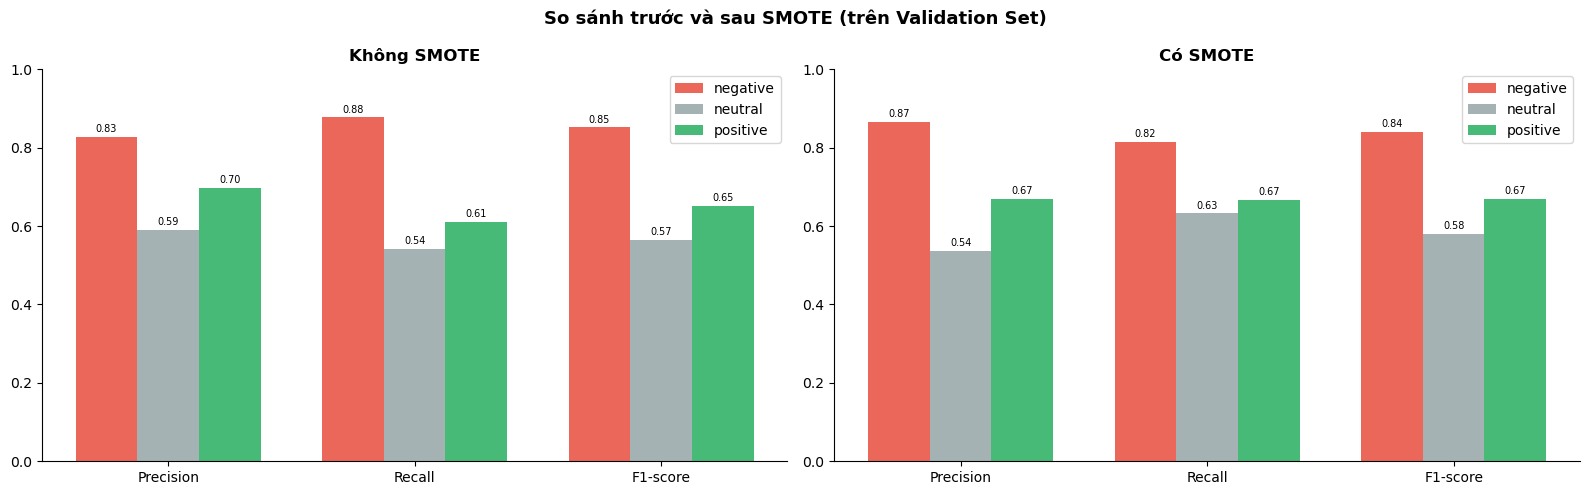

In [7]:
# ==================== BIỂU ĐỒ SO SÁNH TRƯỚC VÀ SAU SMOTE (trên Validation) ====================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('So sánh trước và sau SMOTE (trên Validation Set)', 
             fontsize=13, fontweight='bold')

versions = {'Không SMOTE': y_pred_after, 'Có SMOTE': y_pred_smote}
metrics  = ['precision', 'recall', 'f1-score']
colors   = {'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#27ae60'}
x, width = np.arange(len(metrics)), 0.25

for ax, (version, y_pred) in zip(axes, versions.items()):
    report = classification_report(y_val, y_pred, 
                                   target_names=LABELS, output_dict=True)
    
    for i, cls in enumerate(LABELS):
        ax.bar(x + i*width, [report[cls][m] for m in metrics],
               width, label=cls, color=colors[cls], alpha=0.85)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(['Precision', 'Recall', 'F1-score'])
    ax.set_ylim(0, 1.0)
    ax.set_title(version, fontweight='bold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    
    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

plt.tight_layout()
plt.savefig('smote_comparison_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ====================== LƯU BEST MODEL (Cell cuối cùng) ======================

best_model = search.best_estimator_

import joblib
import json

# Lưu model bằng joblib (khuyến nghị cho XGBoost)
joblib.dump(best_model, 'best_xgboost_model.pkl')

# Lưu best parameters
with open('best_params.json', 'w') as f:
    json.dump(search.best_params_, f, indent=4)

print(" Best model đã được lưu thành công!")
print("   • best_xgboost_model.pkl")
print("   • best_params.json")
print(f"   Best CV F1 : {search.best_score_:.4f}")

 Best model đã được lưu thành công!
   • best_xgboost_model.pkl
   • best_params.json
   Best CV F1 : 0.7633
